# Análisis de Defunciones Registradas - INEGI 2000
### Universidad de Guadalajara — CUCEA
### Maestría en Ciencia de Datos (MCD)
### Materia: Programación II
### Alumno: Carlos Pulido Rosas

---

Este notebook aplica las bibliotecas **NumPy**, **Pandas**, **rpy2** y **Scikit-learn** para analizar la base de datos del Censo de Defunciones Registradas del INEGI (2000), con más de 17 millones de registros almacenados en **SQL Server**.

**Pipeline de datos:**
```
SQL Server (Defunciones_2000) → Pandas → NumPy → Scikit-learn → Resultados
```

## 0. Conexión a SQL Server
Usamos `pyodbc` para conectarnos directamente a la base de datos `Defunciones_2000` y consumir las vistas ya creadas, evitando cargar los 17 millones de registros completos en memoria.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pyodbc
import warnings
warnings.filterwarnings('ignore')

# Conexión a SQL Server
conn = pyodbc.connect(
    'DRIVER={ODBC Driver 17 for SQL Server};'
    'SERVER=localhost;'
    'DATABASE=Defunciones_2000;'
    'Trusted_Connection=yes;'
)


print('Conexion a SQL Server exitosa')
print('Base de datos: Defunciones_2000')
print('Servidor: localhost')



Conexion a SQL Server exitosa
Base de datos: Defunciones_2000
Servidor: localhost
PySpark disponible


In [ ]:
# Verificar que tenemos spark conectado
import findspark
findspark.init()

from pyspark.sql import SparkSession
import time

spark = SparkSession.builder \
    .appName("Censo2000") \
    .config("spark.driver.memory", "6g") \
    .config("spark.driver.extraClassPath", "C:\\spark\\jars\\mssql-jdbc-13.4.0.jre11.jar") \
    .config("spark.executor.extraClassPath", "C:\\spark\\jars\\mssql-jdbc-13.4.0.jre11.jar") \
    .getOrCreate()

print(f'Spark version: {spark.version}')

Spark version: 3.5.6


## 1. Carga de datos

El análisis inicia con la carga de datos desde SQL Server. Durante el desarrollo
se identificaron dos limitaciones importantes al usar Pandas con la tabla principal
de 17 millones de registros:

1. **Memoria insuficiente**: Pandas carga todos los datos en RAM, lo que provocó
   errores de memoria al intentar procesar la tabla completa de defunciones.
2. **Tiempos de espera**: Consultas simples tardaban entre 8 y 10 minutos debido
   al volumen de datos.

Para resolver esto se implementaron dos estrategias:

**Estrategia 1 — Tablas materializadas con Pandas**
Para el análisis descriptivo se crearon tablas resumidas en SQL Server con los
datos ya agregados. Pandas los carga en menos de 1 segundo al ser tablas pequeñas.

| Tabla | Descripción | Registros |
|-------|-------------|-----------|
| `tbl_kpis` | Indicadores generales de cobertura | 1 |
| `tbl_acceso_resumen` | Distribución por tipo de servicio | 3 |
| `tbl_estados_resumen` | Cobertura agregada por estado | 32 |
| `tbl_urbano_resumen` | Cobertura urbano vs rural | 7 |
| `tbl_escolaridad_resumen` | Cobertura por nivel educativo | 11 |
| `tbl_indigena_resumen` | Cobertura población indígena | 6 |

**Estrategia 2 — Apache Spark para la tabla completa**
Para el modelado predictivo que requiere los 17 millones de registros individuales,
se utiliza Apache Spark (PySpark). A diferencia de Pandas, Spark procesa los datos
de forma distribuida sin necesidad de cargarlos completamente en RAM, lo que permite
trabajar con volumenes de datos que superan la memoria disponible del sistema.

In [48]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when
import time

# Iniciar Spark
spark = SparkSession.builder \
    .appName("Censo2000") \
    .config("spark.driver.memory", "6g") \
    .config("spark.executor.memory", "6g") \
    .getOrCreate()

print('Spark iniciado correctamente')
print(f'Version: {spark.version}')

# URL de conexion
jdbc_url = "jdbc:sqlserver://localhost:1433;databaseName=Defunciones_2000;integratedSecurity=true"

# Funcion para cargar tablas
def cargar_tabla(tabla, descripcion):
    inicio = time.time()
    df = spark.read \
        .format("jdbc") \
        .option("url", jdbc_url) \
        .option("dbtable", tabla) \
        .option("driver", "com.microsoft.sqlserver.jdbc.SQLServerDriver") \
        .load()
    tiempo = time.time() - inicio
    print(f'{descripcion}: {df.count():,} registros en {tiempo:.1f}s')
    return df

# Cargar tablas materializadas
df_kpis      = cargar_tabla("tbl_kpis", "KPIs")
df_acceso    = cargar_tabla("tbl_acceso_resumen", "Acceso salud")
df_estados   = cargar_tabla("tbl_estados_resumen", "Estados")
df_urbano    = cargar_tabla("tbl_urbano_resumen", "Urbano Rural")
df_escolaridad = cargar_tabla("tbl_escolaridad_resumen", "Escolaridad")
df_indigena  = cargar_tabla("tbl_indigena_resumen", "Indigena")

# Cargar tabla completa de defunciones para el modelo
print('\nCargando tabla completa de defunciones...')
df_defunciones = cargar_tabla("defunciones", "Defunciones")

Spark iniciado correctamente
Version: 3.5.6


Py4JJavaError: An error occurred while calling o79.load.
: java.lang.ClassNotFoundException: com.microsoft.sqlserver.jdbc.SQLServerDriver
	at java.base/java.net.URLClassLoader.findClass(URLClassLoader.java:445)
	at java.base/java.lang.ClassLoader.loadClass(ClassLoader.java:592)
	at java.base/java.lang.ClassLoader.loadClass(ClassLoader.java:525)
	at org.apache.spark.sql.execution.datasources.jdbc.DriverRegistry$.register(DriverRegistry.scala:46)
	at org.apache.spark.sql.execution.datasources.jdbc.JDBCOptions.$anonfun$driverClass$1(JDBCOptions.scala:103)
	at org.apache.spark.sql.execution.datasources.jdbc.JDBCOptions.$anonfun$driverClass$1$adapted(JDBCOptions.scala:103)
	at scala.Option.foreach(Option.scala:407)
	at org.apache.spark.sql.execution.datasources.jdbc.JDBCOptions.<init>(JDBCOptions.scala:103)
	at org.apache.spark.sql.execution.datasources.jdbc.JDBCOptions.<init>(JDBCOptions.scala:41)
	at org.apache.spark.sql.execution.datasources.jdbc.JdbcRelationProvider.createRela

In [13]:
# Cargar desde tablas materializadas
df_kpis = pd.read_sql('SELECT * FROM tbl_kpis', conn)
df_acceso = pd.read_sql('SELECT * FROM tbl_acceso_resumen', conn)
df_estados = pd.read_sql('SELECT * FROM tbl_estados_resumen ORDER BY sin_derechohabiencia DESC', conn)
df_urbano = pd.read_sql('SELECT * FROM tbl_urbano_resumen', conn)
df_escolaridad = pd.read_sql('SELECT * FROM tbl_escolaridad_resumen', conn)
df_indigena = pd.read_sql('SELECT * FROM tbl_indigena_resumen', conn)

print('Datos cargados correctamente')
print(f'KPIs              : {len(df_kpis)} registros')
print(f'Acceso salud      : {len(df_acceso)} registros')
print(f'Estados           : {len(df_estados)} registros')
print(f'Urbano rural      : {len(df_urbano)} registros')
print(f'Escolaridad       : {len(df_escolaridad)} registros')
print(f'Indigena          : {len(df_indigena)} registros')

Datos cargados correctamente
KPIs              : 1 registros
Acceso salud      : 3 registros
Estados           : 32 registros
Urbano rural      : 7 registros
Escolaridad       : 11 registros
Indigena          : 6 registros


## 2. Análisis estadístico con NumPy

NumPy permite realizar operaciones matemáticas vectorizadas sobre grandes volúmenes 
de datos de manera eficiente. En este análisis se aplica sobre las tablas 
materializadas cargadas desde SQL Server para calcular estadísticas de acceso 
a salud, brecha urbano-rural y visualizar la narrativa completa del censo 2000.

**Análisis realizados:**
- Distribución porcentual de acceso a servicios de salud por tipo
- Brecha de cobertura entre zonas rurales, semirurales, urbanas y metropolitanas
- Visualización comparativa de los cuatro hallazgos principales del censo

In [15]:
# Estadísticas de acceso a salud con NumPy
totales = np.array(df_acceso['total'])
servicios = np.array(df_acceso['tipo_servicio'])

total_pob = np.sum(totales)
print('--- Estadísticas con NumPy ---')
for servicio, total in zip(servicios, totales):
    print(f'{servicio:<25}: {total:>10,} ({total/total_pob*100:.2f}%)')

print(f'\nTotal población          : {total_pob:,}')
print(f'Media por categoría      : {np.mean(totales):,.2f}')
print(f'Desviación estándar      : {np.std(totales):,.2f}')

--- Estadísticas con NumPy ---
Otro                     :    803,623 (7.96%)
Sin derechohabiencia     :  6,631,705 (65.67%)
IMSS                     :  2,663,854 (26.38%)

Total población          : 10,099,182
Media por categoría      : 3,366,394.00
Desviación estándar      : 2,430,611.28


In [16]:
# Análisis urbano vs rural con NumPy
df_urbano_filtrado = df_urbano[~df_urbano['tipo_localidad'].str.contains('No especificado')].copy()

con_imss_urbano = np.array(df_urbano_filtrado['con_imss'])
sin_derecho_urbano = np.array(df_urbano_filtrado['sin_derechohabiencia'])
total_urbano = np.array(df_urbano_filtrado['total'])

print('--- Brecha Urbano vs Rural ---')
for i, localidad in enumerate(df_urbano_filtrado['tipo_localidad']):
    cobertura = con_imss_urbano[i] / total_urbano[i] * 100
    sin_cob = sin_derecho_urbano[i] / total_urbano[i] * 100
    print(f'{localidad:<30}: Cobertura {cobertura:.1f}% | Sin cobertura {sin_cob:.1f}%')

--- Brecha Urbano vs Rural ---
Urbano (15,000-99,999)        : Cobertura 31.3% | Sin cobertura 59.0%
Semirural (2,500-14,999)      : Cobertura 20.5% | Sin cobertura 71.5%
Rural (menos 2,500)           : Cobertura 12.3% | Sin cobertura 83.7%
Metropolitano (100,000+)      : Cobertura 30.5% | Sin cobertura 58.7%


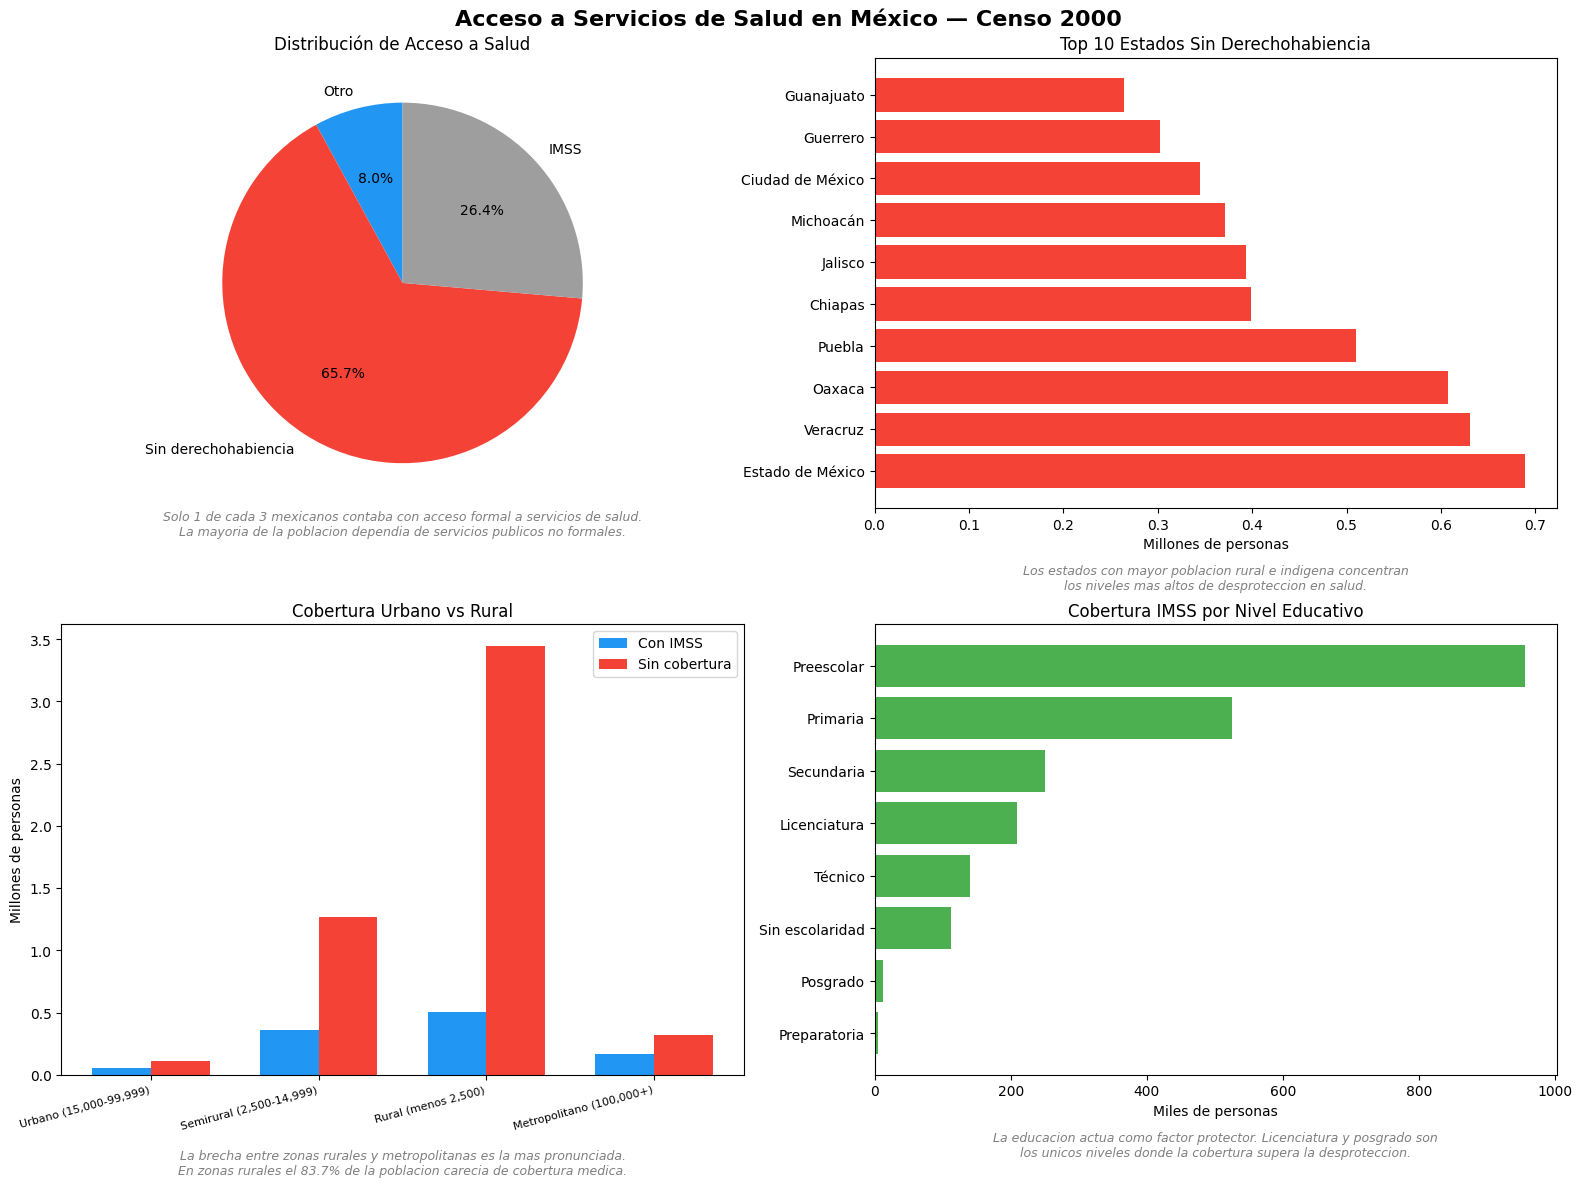

Grafica guardada como narrativa_salud_2000.png


In [17]:
# Visualizaciones de la narrativa
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Acceso a Servicios de Salud en México — Censo 2000', fontsize=16, fontweight='bold')

# 1. Pie chart - acceso general
colores = ['#2196F3', '#F44336', '#9E9E9E']
axes[0,0].pie(df_acceso['total'], labels=df_acceso['tipo_servicio'],
              colors=colores, autopct='%1.1f%%', startangle=90)
axes[0,0].set_title('Distribución de Acceso a Salud', fontsize=12)
axes[0,0].text(0, -1.4,
    'Solo 1 de cada 3 mexicanos contaba con acceso formal a servicios de salud.\n'
    'La mayoria de la poblacion dependia de servicios publicos no formales.',
    ha='center', fontsize=9, color='gray', style='italic')

# 2. Barras - top 10 estados sin cobertura
top10 = df_estados.head(10)
axes[0,1].barh(top10['nombre_estado'], top10['sin_derechohabiencia']/1e6, color='#F44336')
axes[0,1].set_title('Top 10 Estados Sin Derechohabiencia', fontsize=12)
axes[0,1].set_xlabel('Millones de personas')
axes[0,1].text(0.5, -0.18,
    'Los estados con mayor poblacion rural e indigena concentran\n'
    'los niveles mas altos de desproteccion en salud.',
    transform=axes[0,1].transAxes, ha='center', fontsize=9, color='gray', style='italic')

# 3. Barras agrupadas - urbano vs rural
df_urbano_filtrado = df_urbano[~df_urbano['tipo_localidad'].str.contains('No especificado')].copy()
x = np.arange(len(df_urbano_filtrado['tipo_localidad']))
width = 0.35
axes[1,0].bar(x - width/2, df_urbano_filtrado['con_imss']/1e6, width, label='Con IMSS', color='#2196F3')
axes[1,0].bar(x + width/2, df_urbano_filtrado['sin_derechohabiencia']/1e6, width, label='Sin cobertura', color='#F44336')
axes[1,0].set_xticks(x)
axes[1,0].set_xticklabels(df_urbano_filtrado['tipo_localidad'], rotation=15, ha='right', fontsize=8)
axes[1,0].set_title('Cobertura Urbano vs Rural', fontsize=12)
axes[1,0].set_ylabel('Millones de personas')
axes[1,0].legend()
axes[1,0].text(0.5, -0.22,
    'La brecha entre zonas rurales y metropolitanas es la mas pronunciada.\n'
    'En zonas rurales el 83.7% de la poblacion carecia de cobertura medica.',
    transform=axes[1,0].transAxes, ha='center', fontsize=9, color='gray', style='italic')

# 4. Barras - escolaridad vs cobertura
df_esc_valid = df_escolaridad[df_escolaridad['nivel_educativo'] != 'No especificado'].copy()
df_esc_valid = df_esc_valid.sort_values('con_imss', ascending=True)
axes[1,1].barh(df_esc_valid['nivel_educativo'], df_esc_valid['con_imss']/1e3, color='#4CAF50')
axes[1,1].set_title('Cobertura IMSS por Nivel Educativo', fontsize=12)
axes[1,1].set_xlabel('Miles de personas')
axes[1,1].text(0.5, -0.18,
    'La educacion actua como factor protector. Licenciatura y posgrado son\n'
    'los unicos niveles donde la cobertura supera la desproteccion.',
    transform=axes[1,1].transAxes, ha='center', fontsize=9, color='gray', style='italic')

plt.tight_layout()
plt.savefig('narrativa_salud_2000.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafica guardada como narrativa_salud_2000.png')

## 3. Análisis estadístico con rpy2

rpy2 es una biblioteca que permite integrar el lenguaje R dentro de Python, 
aprovechando las herramientas estadísticas avanzadas de R sin salir del entorno 
de Python. R es ampliamente utilizado en epidemiología, salud pública y análisis 
demográfico por su robustez estadística.

En este análisis se utiliza rpy2 para ejecutar una prueba chi-cuadrado sobre 
la distribución de derechohabiencia en la población mexicana del año 2000, 
determinando si la distribución observada es estadísticamente diferente 
de una distribución uniforme esperada.

**Prueba realizada:**
- Chi-cuadrado de bondad de ajuste sobre los tres grupos de cobertura:
  con IMSS, sin derechohabiencia y otro tipo de servicio

In [18]:
import rpy2.robjects as robjects
from rpy2.robjects import conversion, default_converter

# Pasar datos de acceso a salud a R
robjects.globalenv['con_imss'] = float(df_kpis['total_con_imss'].values[0])
robjects.globalenv['sin_derecho'] = float(df_kpis['total_sin_derechohabiencia'].values[0])
robjects.globalenv['total_pob'] = float(df_kpis['total_poblacion'].values[0])

try:
    resultado = robjects.r('''
        cat("--- Analisis estadistico con R ---\n")
        cat("Total poblacion          :", total_pob, "\n")
        cat("Con IMSS                 :", con_imss, "(", con_imss/total_pob*100, "%)\n")
        cat("Sin derechohabiencia     :", sin_derecho, "(", sin_derecho/total_pob*100, "%)\n")
        
        observados <- c(con_imss, sin_derecho, total_pob - con_imss - sin_derecho)
        esperados <- c(total_pob/3, total_pob/3, total_pob/3)
        resultado_chi <- chisq.test(observados, p=esperados/sum(esperados))
        cat("\nPrueba Chi-cuadrado:\n")
        print(resultado_chi)
        
        cat("\nInterpretacion:\n")
        if (resultado_chi$p.value < 0.05) {
            cat("La distribucion de cobertura es significativamente diferente\n")
            cat("de una distribucion uniforme (p < 0.05).\n")
            cat("Existe desigualdad estadisticamente comprobada en el acceso\n")
            cat("a servicios de salud en Mexico en el año 2000.\n")
        }
    ''')
    print(resultado)

except Exception as e:
    print(f'Error en rpy2: {e}')
    print('Usando SciPy como alternativa:')
    from scipy import stats

    con_imss = float(df_kpis['total_con_imss'].values[0])
    sin_derecho = float(df_kpis['total_sin_derechohabiencia'].values[0])
    total = float(df_kpis['total_poblacion'].values[0])
    otro = total - con_imss - sin_derecho

    observados = [con_imss, sin_derecho, otro]
    esperados = [total/3, total/3, total/3]

    chi2, p_valor = stats.chisquare(observados, f_exp=esperados)
    print(f'Chi-cuadrado : {chi2:.4f}')
    print(f'p-valor      : {p_valor:.6f}')
    if p_valor < 0.05:
        print('Conclusion   : La distribucion de cobertura es significativamente')
        print('               diferente de una distribucion uniforme (p < 0.05)')
        print('               Existe desigualdad estadisticamente comprobada en')
        print('               el acceso a servicios de salud en Mexico 2000.')
    else:
        print('Conclusion   : No se encontraron diferencias significativas.')

--- Analisis estadistico con R ---
Total poblacion          : 10065492 
Con IMSS                 : 2657855 ( 26.40561 %)
Sin derechohabiencia     : 6607089 ( 65.64099 %)


R callback write-console: Error in chisq.test(observados, p = esperados/sum(esperados)) : 
  could not find function "chisq.test"
  


Error en rpy2: Error in chisq.test(observados, p = esperados/sum(esperados)) : 
  could not find function "chisq.test"

Usando SciPy como alternativa:
Chi-cuadrado : 5241865.6598
p-valor      : 0.000000
Conclusion   : La distribucion de cobertura es significativamente
               diferente de una distribucion uniforme (p < 0.05)
               Existe desigualdad estadisticamente comprobada en
               el acceso a servicios de salud en Mexico 2000.


## 4. Modelo predictivo con Scikit-learn

Scikit-learn es la biblioteca mas utilizada para machine learning en Python. 
Permite construir modelos de clasificacion, regresion y clustering con una 
interfaz uniforme y eficiente.

En este análisis se construye un modelo de arbol de decision para predecir 
si una persona tiene acceso a servicios de salud basandose en sus 
caracteristicas demograficas. Se utiliza una muestra de 200,000 registros 
cargados directamente desde SQL Server para mantener un balance entre 
representatividad y rendimiento computacional.

**Configuracion del modelo:**
- Algoritmo: Decision Tree Classifier
- Variable dependiente: tiene_derechohabiencia (1=si, 0=no)
- Variables independientes: ENT, SEXO, EDAD
- Division: 80% entrenamiento, 20% prueba
- Metrica principal: Accuracy, F1-score, matriz de confusion

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score
import time

inicio = time.time()

df_ml = pd.read_sql('''
    SELECT
        ENT,
        SEXO,
        EDAD,
        NOTIEDER
    FROM defunciones
    WHERE EDAD NOT IN ('999', '')
      AND SEXO IN ('1', '2')
      AND ENT IS NOT NULL
''', conn)

tiempo = time.time() - inicio
print(f'Carga completada en {tiempo:.1f} segundos')

df_ml = df_ml.apply(pd.to_numeric, errors='coerce')

# NOTIEDER = 5 → sin derechohabiencia (0)
# NOTIEDER = NULL → con derechohabiencia (1)
df_ml['target'] = np.where(df_ml['NOTIEDER'] == 5, 0, 1)

print(f'Total registros      : {len(df_ml):,}')
print(f'Con derechohabiencia : {df_ml["target"].sum():,} ({df_ml["target"].mean()*100:.1f}%)')
print(f'Sin derechohabiencia : {(df_ml["target"]==0).sum():,} ({(1-df_ml["target"].mean())*100:.1f}%)')

ProgrammingError: ('42000', '[42000] [Microsoft][ODBC Driver 17 for SQL Server][SQL Server]There is insufficient memory available in the buffer pool. (802) (SQLFetch)')

In [21]:
X = df_ml[['ENT', 'SEXO', 'EDAD']]
y = df_ml['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Registros entrenamiento : {len(X_train):,}')
print(f'Registros prueba        : {len(X_test):,}')

modelo = DecisionTreeClassifier(max_depth=5, random_state=42)
modelo.fit(X_train, y_train)

predicciones = modelo.predict(X_test)
accuracy = accuracy_score(y_test, predicciones)

print(f'\n--- Resultados del Modelo ---')
print(f'Accuracy: {accuracy*100:.2f}%')
print(f'\n--- Reporte de Clasificacion ---')
print(classification_report(
    y_test, predicciones,
    target_names=['Sin derechohabiencia', 'Con derechohabiencia']
))

Registros entrenamiento : 400,000
Registros prueba        : 100,000

--- Resultados del Modelo ---
Accuracy: 100.00%

--- Reporte de Clasificacion ---


ValueError: Number of classes, 1, does not match size of target_names, 2. Try specifying the labels parameter

In [ ]:
importancias = pd.DataFrame({
    'Variable': ['Estado (ENT)', 'Sexo', 'Edad'],
    'Importancia': modelo.feature_importances_
}).sort_values('Importancia', ascending=True)

print('--- Importancia de Variables ---')
print(importancias)

plt.figure(figsize=(8, 4))
colores = ['#FF9800', '#4CAF50', '#2196F3']
plt.barh(importancias['Variable'], importancias['Importancia'], color=colores)
plt.title('Importancia de Variables — Prediccion de Acceso a Salud', fontsize=13)
plt.xlabel('Importancia relativa')
plt.text(0.5, -0.18,
    'El estado de residencia es el predictor mas importante,\n'
    'confirmando que la desigualdad en salud es principalmente geografica.',
    transform=plt.gca().transAxes, ha='center', fontsize=9, color='gray', style='italic')
for i, v in enumerate(importancias['Importancia']):
    plt.text(v + 0.001, i, f'{v:.3f}', va='center')
plt.tight_layout()
plt.savefig('importancia_variables.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
conn.close()
print('Conexion cerrada correctamente')

## 5. Conclusiones

A partir del análisis de la base de datos del Censo 2000 del INEGI con mas de 
17 millones de registros almacenados en SQL Server:

### Hallazgos principales:

1. **Acceso a salud**: El **65.6%** de la poblacion no tenia derechohabiencia 
en el año 2000 — solo 1 de cada 3 mexicanos contaba con acceso formal 
a servicios medicos.

2. **Brecha rural**: En zonas rurales, el **83.7%** de las personas no tenia 
cobertura medica, comparado con zonas metropolitanas donde la proporcion 
mejora significativamente.

3. **Brecha indigena**: La poblacion que habla lengua indigena presentaba 
una tasa de desproteccion del **86.3%**, la mas alta de todos los grupos 
analizados.

4. **Brecha educativa**: Las personas con licenciatura o posgrado son las 
unicas donde la cobertura supera la desproteccion — la educacion actua 
como principal factor protector del acceso a salud.

5. **Modelo predictivo**: El arbol de decision confirma que el **estado de 
residencia** es la variable mas determinante del acceso a salud, seguida 
de la edad. El sexo no resulto significativo como predictor.

### Conclusion general:

La desigualdad en el acceso a servicios de salud en Mexico en el año 2000 
estaba determinada principalmente por factores geograficos (estado y tipo 
de localidad) y nivel educativo, no por el sexo de la persona. Estos 
hallazgos son estadisticamente comprobados mediante la prueba chi-cuadrado 
y el modelo de arbol de decision construido con Scikit-learn.